In [36]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)


In [37]:
from scipy.stats import mode
from sklearn import datasets, tree
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (roc_auc_score, confusion_matrix, accuracy_score,
                             precision_score, recall_score, f1_score,
                             classification_report)

In [38]:


from imblearn.over_sampling import SMOTE
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.utils import concordance_index



In [39]:
import matplotlib.pyplot as plt
import seaborn as sns


In [127]:
import pandas as pd

data =pd.read_csv("final_dataset_PART1.csv")

print(f'Dataset Shape: {data.shape}')
print(f' Dataset Memory Usage: {data.memory_usage().sum() / 1024 ** 2:.2f} MB')

Dataset Shape: (1976, 62)
 Dataset Memory Usage: 0.43 MB


In [128]:
print(f'Dataset Shape: {data.shape}')


Dataset Shape: (1976, 62)


In [129]:
data["Cancer Type"].value_counts()
data = data.drop('Cancer Type', axis=1)

### Analýza atribútov pomocou Coxovej regresie

##### Najprv som testovala každý atribút samostatne pomocou jednorozmernej Coxovej regresie. Cieľom bolo zistiť, či má daný atribút významný vplyv na prežitie pacientov. Pre každý atribút som vytvorila individuálny model a zaznamenala som jeho p-hodnotu a HR (Hazard Ratio).

In [130]:
cancer_type = data['event'].value_counts()
print(cancer_type)

event
1    1141
0     835
Name: count, dtype: int64


In [131]:
from lifelines import CoxPHFitter

# Vytvorenie modelu pre 'Age at Diagnosis'
relevant_attributes = ['event', 'time', 'Age at Diagnosis']
age_at_diagnosis_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(age_at_diagnosis_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()


<lifelines.CoxPHFitter: fitted with 1976 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1976
number of events observed = 1141
   partial log-likelihood = -7744.11
         time fit was run = 2025-03-18 15:47:07 UTC

---
                  coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                         
Age at Diagnosis  0.04      1.04      0.00            0.03            0.04                1.03                1.04

                  cmp to     z      p  -log2(p)
covariate                                      
Age at Diagnosis    0.00 13.39 <0.005    133.46
---
Concordance = 0.59
Partial AIC = 15490.21
log-likelihood ratio test = 189.18 on 1 df
-log2(p) of ll-ratio test = 140.58

In [132]:
relevant_attributes = ['event', 'time', 'Type of Breast Surgery']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1976 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1976
number of events observed = 1141
   partial log-likelihood = -7812.32
         time fit was run = 2025-03-18 15:47:08 UTC

---
                        coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                               
Type of Breast Surgery  0.45      1.57      0.06            0.33            0.58                1.39                1.78

                        cmp to    z      p  -log2(p)
covariate                                           
Type of Breast Surgery    0.00 7.10 <0.005     39.52
---
Concordance = 0.56
Partial AIC = 15626.63
log-likelihood ratio test = 52.77 on 1 df
-log2(p) of ll-ratio test = 41.27

In [133]:
relevant_attributes = ['event', 'time', 'Cellularity']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1976 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1976
number of events observed = 1141
   partial log-likelihood = -7838.65
         time fit was run = 2025-03-18 15:47:09 UTC

---
             coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                    
Cellularity  0.01      1.01      0.04           -0.07            0.10                0.93                1.11

             cmp to    z    p  -log2(p)
covariate                              
Cellularity    0.00 0.30 0.76      0.39
---
Concordance = 0.51
Partial AIC = 15679.31
log-likelihood ratio test = 0.09 on 1 df
-log2(p) of ll-ratio test = 0.39

In [134]:
relevant_attributes = ['event', 'time', 'Chemotherapy']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1976 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1976
number of events observed = 1141
   partial log-likelihood = -7834.28
         time fit was run = 2025-03-18 15:47:11 UTC

---
              coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                     
Chemotherapy  0.23      1.26      0.08            0.08            0.38                1.08                1.46

              cmp to    z      p  -log2(p)
covariate                                 
Chemotherapy    0.00 3.04 <0.005      8.73
---
Concordance = 0.54
Partial AIC = 15670.57
log-likelihood ratio test = 8.83 on 1 df
-log2(p) of ll-ratio test = 8.40

In [135]:
relevant_attributes = ['event', 'time', 'Cohort']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1976 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1976
number of events observed = 1141
   partial log-likelihood = -7835.68
         time fit was run = 2025-03-18 15:47:12 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
Cohort     0.06      1.07      0.03            0.01            0.11                1.01                1.12

           cmp to    z    p  -log2(p)
covariate                            
Cohort       0.00 2.46 0.01      6.18
---
Concordance = 0.52
Partial AIC = 15673.36
log-likelihood ratio test = 6.03 on 1 df
-log2(p) of ll-ratio test = 6.15

In [136]:
relevant_attributes = ['event', 'time', 'ER status measured by IHC']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1976 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1976
number of events observed = 1141
   partial log-likelihood = -7837.30
         time fit was run = 2025-03-18 15:47:12 UTC

---
                           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                  
ER status measured by IHC -0.12      0.89      0.07           -0.26            0.02                0.77                1.02

                           cmp to     z    p  -log2(p)
covariate                                             
ER status measured by IHC    0.00 -1.69 0.09      3.46
---
Concordance = 0.54
Partial AIC = 15676.61
log-likelihood ratio test = 2.79 on 1 df
-log2(p) of ll-ratio test = 3.40

In [137]:
relevant_attributes = ['event', 'time', 'ER Status']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1976 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1976
number of events observed = 1141
   partial log-likelihood = -7836.63
         time fit was run = 2025-03-18 15:47:13 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
ER Status -0.15      0.86      0.07           -0.28           -0.01                0.75                0.99

           cmp to     z    p  -log2(p)
covariate                             
ER Status    0.00 -2.06 0.04      4.67
---
Concordance = 0.54
Partial AIC = 15675.25
log-likelihood ratio test = 4.14 on 1 df
-log2(p) of ll-ratio test = 4.58

In [138]:
relevant_attributes = ['event', 'time', 'Neoplasm Histologic Grade']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1976 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1976
number of events observed = 1141
   partial log-likelihood = -7825.35
         time fit was run = 2025-03-18 15:47:13 UTC

---
                           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                  
Neoplasm Histologic Grade  0.24      1.28      0.05            0.15            0.34                1.16                1.40

                           cmp to    z      p  -log2(p)
covariate                                              
Neoplasm Histologic Grade    0.00 5.08 <0.005     21.31
---
Concordance = 0.56
Partial AIC = 15652.71
log-likelihood ratio test = 26.69 on 1 df
-log2(p) of ll-ratio test = 22.00

In [139]:
relevant_attributes = ['event', 'time', 'HER2 Status']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1976 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1976
number of events observed = 1141
   partial log-likelihood = -7829.78
         time fit was run = 2025-03-18 15:47:14 UTC

---
             coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                    
HER2 Status  0.38      1.47      0.09            0.21            0.55                1.24                1.74

             cmp to    z      p  -log2(p)
covariate                                
HER2 Status    0.00 4.42 <0.005     16.65
---
Concordance = 0.53
Partial AIC = 15661.56
log-likelihood ratio test = 17.83 on 1 df
-log2(p) of ll-ratio test = 15.34

In [140]:
relevant_attributes = ['event', 'time', 'Hormone Therapy']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1976 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1976
number of events observed = 1141
   partial log-likelihood = -7831.33
         time fit was run = 2025-03-18 15:47:14 UTC

---
                 coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                        
Hormone Therapy  0.24      1.27      0.06            0.11            0.36                1.12                1.43

                 cmp to    z      p  -log2(p)
covariate                                    
Hormone Therapy    0.00 3.80 <0.005     12.78
---
Concordance = 0.51
Partial AIC = 15664.67
log-likelihood ratio test = 14.73 on 1 df
-log2(p) of ll-ratio test = 12.98

In [141]:
cancer_type = data['Inferred Menopausal State'].value_counts()
print(cancer_type)

Inferred Menopausal State
1    1552
0     424
Name: count, dtype: int64


In [142]:
relevant_attributes = ['event', 'time', 'Inferred Menopausal State']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1976 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1976
number of events observed = 1141
   partial log-likelihood = -7816.55
         time fit was run = 2025-03-18 15:47:15 UTC

---
                           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                  
Inferred Menopausal State  0.52      1.67      0.08            0.35            0.68                1.43                1.97

                           cmp to    z      p  -log2(p)
covariate                                              
Inferred Menopausal State    0.00 6.29 <0.005     31.52
---
Concordance = 0.52
Partial AIC = 15635.10
log-likelihood ratio test = 44.30 on 1 df
-log2(p) of ll-ratio test = 35.04

In [143]:
relevant_attributes = ['event', 'time', 'Primary Tumor Laterality']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1976 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1976
number of events observed = 1141
   partial log-likelihood = -7837.11
         time fit was run = 2025-03-18 15:47:18 UTC

---
                          coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                 
Primary Tumor Laterality  0.11      1.11      0.06           -0.01            0.22                0.99                1.25

                          cmp to    z    p  -log2(p)
covariate                                           
Primary Tumor Laterality    0.00 1.78 0.08      3.73
---
Concordance = 0.52
Partial AIC = 15676.22
log-likelihood ratio test = 3.17 on 1 df
-log2(p) of ll-ratio test = 3.74

In [144]:
relevant_attributes = ['event', 'time', 'Lymph nodes examined positive']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1976 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1976
number of events observed = 1141
   partial log-likelihood = -7782.82
         time fit was run = 2025-03-18 15:47:19 UTC

---
                               coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                      
Lymph nodes examined positive  0.06      1.07      0.00            0.06            0.07                1.06                1.08

                               cmp to     z      p  -log2(p)
covariate                                                   
Lymph nodes examined positive    0.00 13.51 <0.005    135.83
---
Concordance = 0.60
Partial AIC = 15567.64
log-likelihood ratio test = 111.76 on 1 df
-log2(p) of ll-ratio test = 84.35

In [145]:
relevant_attributes = ['event', 'time', 'Mutation Count']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1976 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1976
number of events observed = 1141
   partial log-likelihood = -7838.22
         time fit was run = 2025-03-18 15:47:20 UTC

---
                coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                       
Mutation Count  0.01      1.01      0.01           -0.01            0.02                0.99                1.02

                cmp to    z    p  -log2(p)
covariate                                 
Mutation Count    0.00 1.00 0.32      1.66
---
Concordance = 0.51
Partial AIC = 15678.44
log-likelihood ratio test = 0.96 on 1 df
-log2(p) of ll-ratio test = 1.61

In [146]:
relevant_attributes = ['event', 'time', 'Nottingham prognostic index']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1976 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1976
number of events observed = 1141
   partial log-likelihood = -7784.04
         time fit was run = 2025-03-18 15:47:20 UTC

---
                             coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                    
Nottingham prognostic index  0.28      1.33      0.03            0.23            0.34                1.26                1.40

                             cmp to     z      p  -log2(p)
covariate                                                 
Nottingham prognostic index    0.00 10.40 <0.005     81.77
---
Concordance = 0.63
Partial AIC = 15570.09
log-likelihood ratio test = 109.31 on 1 df
-log2(p) of ll-ratio test = 82.57

In [147]:
relevant_attributes = ['event', 'time', 'PR Status']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1976 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1976
number of events observed = 1141
   partial log-likelihood = -7831.03
         time fit was run = 2025-03-18 15:47:22 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
PR Status -0.23      0.79      0.06           -0.35           -0.12                0.71                0.89

           cmp to     z      p  -log2(p)
covariate                               
PR Status    0.00 -3.93 <0.005     13.50
---
Concordance = 0.55
Partial AIC = 15664.05
log-likelihood ratio test = 15.34 on 1 df
-log2(p) of ll-ratio test = 13.45

In [148]:
relevant_attributes = ['event', 'time', 'Radio Therapy']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1976 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1976
number of events observed = 1141
   partial log-likelihood = -7835.04
         time fit was run = 2025-03-18 15:47:23 UTC

---
               coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                      
Radio Therapy -0.16      0.85      0.06           -0.28           -0.04                0.76                0.96

               cmp to     z    p  -log2(p)
covariate                                 
Radio Therapy    0.00 -2.71 0.01      7.23
---
Concordance = 0.52
Partial AIC = 15672.08
log-likelihood ratio test = 7.32 on 1 df
-log2(p) of ll-ratio test = 7.19

In [149]:
relevant_attributes = ['event', 'time', 'Relapse Free Status (Months)']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1976 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1976
number of events observed = 1141
   partial log-likelihood = -7097.49
         time fit was run = 2025-03-18 15:47:23 UTC

---
                              coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                     
Relapse Free Status (Months) -0.02      0.98      0.00           -0.02           -0.02                0.98                0.98

                              cmp to      z      p  -log2(p)
covariate                                                   
Relapse Free Status (Months)    0.00 -36.05 <0.005    942.80
---
Concordance = 0.92
Partial AIC = 14196.98
log-likelihood ratio test = 1482.42 on 1 df
-log2(p) of ll-ratio test = inf

In [150]:
relevant_attributes = ['event', 'time', 'Relapse Free Status']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1976 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1976
number of events observed = 1141
   partial log-likelihood = -7585.83
         time fit was run = 2025-03-18 15:47:24 UTC

---
                     coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                            
Relapse Free Status  1.36      3.89      0.06            1.24            1.48                3.45                4.39

                     cmp to     z      p  -log2(p)
covariate                                         
Relapse Free Status    0.00 22.10 <0.005    356.97
---
Concordance = 0.69
Partial AIC = 15173.66
log-likelihood ratio test = 505.74 on 1 df
-log2(p) of ll-ratio test = 369.63

In [151]:
relevant_attributes = ['event', 'time', 'Tumor Size']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1976 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1976
number of events observed = 1141
   partial log-likelihood = -7798.39
         time fit was run = 2025-03-18 15:47:25 UTC

---
            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                   
Tumor Size  0.01      1.01      0.00            0.01            0.02                1.01                1.02

            cmp to     z      p  -log2(p)
covariate                                
Tumor Size    0.00 10.65 <0.005     85.54
---
Concordance = 0.61
Partial AIC = 15598.78
log-likelihood ratio test = 80.61 on 1 df
-log2(p) of ll-ratio test = 61.66

In [152]:
relevant_attributes = ['event', 'time', 'Tumor Stage']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1976 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1976
number of events observed = 1141
   partial log-likelihood = -7779.88
         time fit was run = 2025-03-18 15:47:26 UTC

---
             coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                    
Tumor Stage  0.59      1.80      0.05            0.48            0.69                1.62                2.00

             cmp to     z      p  -log2(p)
covariate                                 
Tumor Stage    0.00 10.88 <0.005     89.10
---
Concordance = 0.59
Partial AIC = 15561.76
log-likelihood ratio test = 117.64 on 1 df
-log2(p) of ll-ratio test = 88.64

In [153]:
relevant_attributes = ['event', 'time', 'Cancer_Type_Breast Invasive Ductal Carcinoma']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1976 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1976
number of events observed = 1141
   partial log-likelihood = -7838.10
         time fit was run = 2025-03-18 15:47:26 UTC

---
                                              coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                                     
Cancer_Type_Breast Invasive Ductal Carcinoma  0.08      1.08      0.07           -0.06            0.22                0.94                1.24

                                              cmp to    z    p  -log2(p)
covariate                                                               
Cancer_Type_Breast Invasive Ductal Carcinoma    0.00 1.08 0.28      1.85
---
Concordance = 0.51
Partial AIC = 15678.20
log-likelihood ratio test = 1.19 on 1 df
-log2(p) of ll-ratio test = 1.86

In [154]:
relevant_attributes = ['event', 'time', 'Cancer_Type_Breast Mixed Ductal and Lobular Carcinoma']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1976 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1976
number of events observed = 1141
   partial log-likelihood = -7838.70
         time fit was run = 2025-03-18 15:47:27 UTC

---
                                                       coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                                              
Cancer_Type_Breast Mixed Ductal and Lobular Carcinoma  0.00      1.00      0.09           -0.18            0.18                0.83                1.20

                                                       cmp to    z    p  -log2(p)
covariate                                                                        
Cancer_Type_Breast Mixed Ductal and Lobular Carcinoma    0.00 0.00 1.00      0.01
---
Concordance = 0.49
Partial AIC = 15679.40
log-likelihood ratio test = 0.00 on 1 df
-log2(p) of ll-ratio test = 0.01

In [155]:
relevant_attributes = ['event', 'time', 'Cancer_Type_Breast Invasive Lobular Carcinoma']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1976 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1976
number of events observed = 1141
   partial log-likelihood = -7838.69
         time fit was run = 2025-03-18 15:47:27 UTC

---
                                               coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                                      
Cancer_Type_Breast Invasive Lobular Carcinoma  0.02      1.02      0.11           -0.20            0.24                0.82                1.27

                                               cmp to    z    p  -log2(p)
covariate                                                                
Cancer_Type_Breast Invasive Lobular Carcinoma    0.00 0.16 0.87      0.19
---
Concordance = 0.50
Partial AIC = 15679.37
log-likelihood ratio test = 0.03 on 1 df
-log2(p) of ll-ratio test = 0.19

In [156]:
relevant_attributes = ['event', 'time', 'Cancer_Type_Invasive Breast Carcinoma']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1976 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1976
number of events observed = 1141
   partial log-likelihood = -7837.47
         time fit was run = 2025-03-18 15:47:28 UTC

---
                                       coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                              
Cancer_Type_Invasive Breast Carcinoma -0.35      0.70      0.24           -0.82            0.11                0.44                1.12

                                       cmp to     z    p  -log2(p)
covariate                                                         
Cancer_Type_Invasive Breast Carcinoma    0.00 -1.48 0.14      2.85
---
Concordance = 0.50
Partial AIC = 15676.93
log-likelihood ratio test = 2.47 on 1 df
-log2(p) of ll-ratio test = 3.10

In [157]:
relevant_attributes = ['event', 'time', 'Cancer_Type_Breast Invasive Mixed Mucinous Carcinoma']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1976 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1976
number of events observed = 1141
   partial log-likelihood = -7838.25
         time fit was run = 2025-03-18 15:47:29 UTC

---
                                                      coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                                             
Cancer_Type_Breast Invasive Mixed Mucinous Carcinoma -0.29      0.75      0.32           -0.91            0.34                0.40                1.40

                                                      cmp to     z    p  -log2(p)
covariate                                                                        
Cancer_Type_Breast Invasive Mixed Mucinous Carcinoma    0.00 -0.90 0.37      1.44
---
Concordance = 0.50
Partial AIC = 15678.51
log-likelihood ratio test = 0.89 on 1 df
-log2(p) of ll-ratio test = 1.53

In [158]:
relevant_attributes = ['event', 'time', 'Subtype_claudin-low']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1976 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1976
number of events observed = 1141
   partial log-likelihood = -7833.47
         time fit was run = 2025-03-18 15:47:30 UTC

---
                     coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                            
Subtype_claudin-low -0.34      0.71      0.11           -0.55           -0.12                0.58                0.88

                     cmp to     z      p  -log2(p)
covariate                                         
Subtype_claudin-low    0.00 -3.08 <0.005      8.94
---
Concordance = 0.51
Partial AIC = 15668.94
log-likelihood ratio test = 10.46 on 1 df
-log2(p) of ll-ratio test = 9.68

In [159]:
relevant_attributes = ['event', 'time', 'Subtype_LumA']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1976 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1976
number of events observed = 1141
   partial log-likelihood = -7827.05
         time fit was run = 2025-03-18 15:47:30 UTC

---
              coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                     
Subtype_LumA -0.30      0.74      0.06           -0.42           -0.18                0.66                0.84

              cmp to     z      p  -log2(p)
covariate                                  
Subtype_LumA    0.00 -4.75 <0.005     18.94
---
Concordance = 0.56
Partial AIC = 15656.10
log-likelihood ratio test = 23.29 on 1 df
-log2(p) of ll-ratio test = 19.46

In [160]:
relevant_attributes = ['event', 'time', 'Subtype_LumB']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1976 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1976
number of events observed = 1141
   partial log-likelihood = -7828.51
         time fit was run = 2025-03-18 15:47:31 UTC

---
              coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                     
Subtype_LumB  0.31      1.36      0.07            0.18            0.44                1.19                1.55

              cmp to    z      p  -log2(p)
covariate                                 
Subtype_LumB    0.00 4.62 <0.005     18.02
---
Concordance = 0.53
Partial AIC = 15659.02
log-likelihood ratio test = 20.38 on 1 df
-log2(p) of ll-ratio test = 17.26

In [161]:
relevant_attributes = ['event', 'time', 'Subtype_Normal']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1976 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1976
number of events observed = 1141
   partial log-likelihood = -7838.46
         time fit was run = 2025-03-18 15:47:32 UTC

---
                coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                       
Subtype_Normal -0.08      0.92      0.12           -0.31            0.15                0.74                1.16

                cmp to     z    p  -log2(p)
covariate                                  
Subtype_Normal    0.00 -0.68 0.50      1.00
---
Concordance = 0.50
Partial AIC = 15678.93
log-likelihood ratio test = 0.47 on 1 df
-log2(p) of ll-ratio test = 1.02

In [162]:
relevant_attributes = ['event', 'time', 'Subtype_Her2']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1976 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1976
number of events observed = 1141
   partial log-likelihood = -7831.21
         time fit was run = 2025-03-18 15:47:33 UTC

---
              coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                     
Subtype_Her2  0.35      1.42      0.09            0.18            0.52                1.20                1.68

              cmp to    z      p  -log2(p)
covariate                                 
Subtype_Her2    0.00 4.04 <0.005     14.18
---
Concordance = 0.52
Partial AIC = 15664.42
log-likelihood ratio test = 14.98 on 1 df
-log2(p) of ll-ratio test = 13.17

In [163]:
relevant_attributes = ['event', 'time', 'Subtype_NC']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1976 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1976
number of events observed = 1141
   partial log-likelihood = -7838.32
         time fit was run = 2025-03-18 15:47:33 UTC

---
            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                   
Subtype_NC  0.42      1.52      0.45           -0.46            1.29                0.63                3.65

            cmp to    z    p  -log2(p)
covariate                             
Subtype_NC    0.00 0.93 0.35      1.50
---
Concordance = 0.50
Partial AIC = 15678.64
log-likelihood ratio test = 0.75 on 1 df
-log2(p) of ll-ratio test = 1.38

In [164]:
relevant_attributes = ['event', 'time', 'HER2_Status_Loss']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1976 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1976
number of events observed = 1141
   partial log-likelihood = -7838.55
         time fit was run = 2025-03-18 15:47:34 UTC

---
                  coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                         
HER2_Status_Loss -0.08      0.93      0.14           -0.36            0.20                0.70                1.23

                  cmp to     z    p  -log2(p)
covariate                                    
HER2_Status_Loss    0.00 -0.53 0.59      0.75
---
Concordance = 0.50
Partial AIC = 15679.11
log-likelihood ratio test = 0.29 on 1 df
-log2(p) of ll-ratio test = 0.76

In [165]:
relevant_attributes = ['event', 'time', 'HER2_Status_Neutral']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1976 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1976
number of events observed = 1141
   partial log-likelihood = -7831.77
         time fit was run = 2025-03-18 15:47:34 UTC

---
                     coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                            
HER2_Status_Neutral -0.25      0.78      0.07           -0.38           -0.12                0.68                0.89

                     cmp to     z      p  -log2(p)
covariate                                         
HER2_Status_Neutral    0.00 -3.79 <0.005     12.71
---
Concordance = 0.54
Partial AIC = 15665.55
log-likelihood ratio test = 13.85 on 1 df
-log2(p) of ll-ratio test = 12.30

In [166]:
relevant_attributes = ['event', 'time', 'HER2_Status_Undef']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1976 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1976
number of events observed = 1141
   partial log-likelihood = -7838.68
         time fit was run = 2025-03-18 15:47:36 UTC

---
                   coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                          
HER2_Status_Undef -0.11      0.89      0.58           -1.25            1.02                0.29                2.77

                   cmp to     z    p  -log2(p)
covariate                                     
HER2_Status_Undef    0.00 -0.20 0.84      0.25
---
Concordance = 0.50
Partial AIC = 15679.36
log-likelihood ratio test = 0.04 on 1 df
-log2(p) of ll-ratio test = 0.25

In [167]:
relevant_attributes = ['event', 'time', 'Tumor_Subtype_Lobular']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1976 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1976
number of events observed = 1141
   partial log-likelihood = -7838.69
         time fit was run = 2025-03-18 15:47:37 UTC

---
                       coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                              
Tumor_Subtype_Lobular  0.02      1.02      0.11           -0.20            0.24                0.82                1.27

                       cmp to    z    p  -log2(p)
covariate                                        
Tumor_Subtype_Lobular    0.00 0.16 0.87      0.19
---
Concordance = 0.50
Partial AIC = 15679.37
log-likelihood ratio test = 0.03 on 1 df
-log2(p) of ll-ratio test = 0.19

In [168]:
relevant_attributes = ['event', 'time', 'Tumor_Subtype_Medullary']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1976 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1976
number of events observed = 1141
   partial log-likelihood = -7837.71
         time fit was run = 2025-03-18 15:47:37 UTC

---
                         coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                
Tumor_Subtype_Medullary -0.36      0.70      0.27           -0.88            0.17                0.41                1.19

                         cmp to     z    p  -log2(p)
covariate                                           
Tumor_Subtype_Medullary    0.00 -1.32 0.19      2.43
---
Concordance = 0.50
Partial AIC = 15677.42
log-likelihood ratio test = 1.98 on 1 df
-log2(p) of ll-ratio test = 2.65

In [169]:
relevant_attributes = ['event', 'time', 'Tumor_Subtype_Mixed']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1976 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1976
number of events observed = 1141
   partial log-likelihood = -7838.70
         time fit was run = 2025-03-18 15:47:38 UTC

---
                     coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                            
Tumor_Subtype_Mixed  0.00      1.00      0.09           -0.18            0.18                0.83                1.20

                     cmp to    z    p  -log2(p)
covariate                                      
Tumor_Subtype_Mixed    0.00 0.00 1.00      0.01
---
Concordance = 0.49
Partial AIC = 15679.40
log-likelihood ratio test = 0.00 on 1 df
-log2(p) of ll-ratio test = 0.01

In [170]:
relevant_attributes = ['event', 'time', 'Tumor_Subtype_Mucinous']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1976 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1976
number of events observed = 1141
   partial log-likelihood = -7838.25
         time fit was run = 2025-03-18 15:47:38 UTC

---
                        coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                               
Tumor_Subtype_Mucinous -0.29      0.75      0.32           -0.91            0.34                0.40                1.40

                        cmp to     z    p  -log2(p)
covariate                                          
Tumor_Subtype_Mucinous    0.00 -0.90 0.37      1.44
---
Concordance = 0.50
Partial AIC = 15678.51
log-likelihood ratio test = 0.89 on 1 df
-log2(p) of ll-ratio test = 1.53

In [171]:
relevant_attributes = ['event', 'time', 'Tumor_Subtype_Other']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1976 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1976
number of events observed = 1141
   partial log-likelihood = -7836.48
         time fit was run = 2025-03-18 15:47:39 UTC

---
                     coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                            
Tumor_Subtype_Other -0.82      0.44      0.45           -1.70            0.06                0.18                1.06

                     cmp to     z    p  -log2(p)
covariate                                       
Tumor_Subtype_Other    0.00 -1.83 0.07      3.88
---
Concordance = 0.50
Partial AIC = 15674.95
log-likelihood ratio test = 4.44 on 1 df
-log2(p) of ll-ratio test = 4.84

In [172]:
relevant_attributes = ['event', 'time', 'Tumor_Subtype_Tubular/ cribriform']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1976 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1976
number of events observed = 1141
   partial log-likelihood = -7832.95
         time fit was run = 2025-03-18 15:47:40 UTC

---
                                   coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                          
Tumor_Subtype_Tubular/ cribriform -1.13      0.32      0.41           -1.94           -0.33                0.14                0.72

                                   cmp to     z    p  -log2(p)
covariate                                                     
Tumor_Subtype_Tubular/ cribriform    0.00 -2.77 0.01      7.46
---
Concordance = 0.51
Partial AIC = 15667.90
log-likelihood ratio test = 11.50 on 1 df
-log2(p) of ll-ratio test = 10.49

In [173]:
relevant_attributes = ['event', 'time', 'IC_10']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1976 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1976
number of events observed = 1141
   partial log-likelihood = -7836.40
         time fit was run = 2025-03-18 15:47:41 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
IC_10     -0.21      0.81      0.10           -0.41           -0.01                0.66                0.99

           cmp to     z    p  -log2(p)
covariate                             
IC_10        0.00 -2.08 0.04      4.75
---
Concordance = 0.49
Partial AIC = 15674.80
log-likelihood ratio test = 4.59 on 1 df
-log2(p) of ll-ratio test = 4.96

In [174]:
relevant_attributes = ['event', 'time', 'IC_2']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1976 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1976
number of events observed = 1141
   partial log-likelihood = -7837.28
         time fit was run = 2025-03-18 15:47:42 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
IC_2       0.25      1.29      0.14           -0.03            0.53                0.97                1.71

           cmp to    z    p  -log2(p)
covariate                            
IC_2         0.00 1.75 0.08      3.65
---
Concordance = 0.51
Partial AIC = 15676.55
log-likelihood ratio test = 2.85 on 1 df
-log2(p) of ll-ratio test = 3.45

In [175]:
relevant_attributes = ['event', 'time', 'IC_3']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1976 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1976
number of events observed = 1141
   partial log-likelihood = -7833.53
         time fit was run = 2025-03-18 15:47:43 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
IC_3      -0.27      0.76      0.09           -0.44           -0.10                0.64                0.90

           cmp to     z      p  -log2(p)
covariate                               
IC_3         0.00 -3.11 <0.005      9.07
---
Concordance = 0.53
Partial AIC = 15669.06
log-likelihood ratio test = 10.34 on 1 df
-log2(p) of ll-ratio test = 9.58

In [176]:
relevant_attributes = ['event', 'time', 'IC_4ER+']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1976 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1976
number of events observed = 1141
   partial log-likelihood = -7836.65
         time fit was run = 2025-03-18 15:47:44 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
IC_4ER+   -0.18      0.83      0.09           -0.37           -0.00                0.69                1.00

           cmp to     z    p  -log2(p)
covariate                             
IC_4ER+      0.00 -1.98 0.05      4.38
---
Concordance = 0.52
Partial AIC = 15675.29
log-likelihood ratio test = 4.10 on 1 df
-log2(p) of ll-ratio test = 4.55

In [177]:
relevant_attributes = ['event', 'time', 'IC_4ER-']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1976 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1976
number of events observed = 1141
   partial log-likelihood = -7838.69
         time fit was run = 2025-03-18 15:47:45 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
IC_4ER-   -0.02      0.98      0.16           -0.33            0.28                0.72                1.32

           cmp to     z    p  -log2(p)
covariate                             
IC_4ER-      0.00 -0.15 0.88      0.19
---
Concordance = 0.50
Partial AIC = 15679.37
log-likelihood ratio test = 0.02 on 1 df
-log2(p) of ll-ratio test = 0.19

In [178]:
relevant_attributes = ['event', 'time', 'IC_5']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1976 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1976
number of events observed = 1141
   partial log-likelihood = -7821.13
         time fit was run = 2025-03-18 15:47:45 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
IC_5       0.60      1.82      0.09            0.41            0.78                1.51                2.18

           cmp to    z      p  -log2(p)
covariate                              
IC_5         0.00 6.39 <0.005     32.51
---
Concordance = 0.53
Partial AIC = 15644.26
log-likelihood ratio test = 35.14 on 1 df
-log2(p) of ll-ratio test = 28.28

In [179]:
relevant_attributes = ['event', 'time', 'IC_6']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1976 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1976
number of events observed = 1141
   partial log-likelihood = -7836.79
         time fit was run = 2025-03-18 15:47:46 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
IC_6       0.27      1.31      0.13            0.01            0.53                1.01                1.71

           cmp to    z    p  -log2(p)
covariate                            
IC_6         0.00 2.03 0.04      4.57
---
Concordance = 0.51
Partial AIC = 15675.58
log-likelihood ratio test = 3.81 on 1 df
-log2(p) of ll-ratio test = 4.30

In [180]:
relevant_attributes = ['event', 'time', 'IC_7']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1976 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1976
number of events observed = 1141
   partial log-likelihood = -7838.04
         time fit was run = 2025-03-18 15:47:48 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
IC_7      -0.11      0.89      0.10           -0.31            0.08                0.73                1.09

           cmp to     z    p  -log2(p)
covariate                             
IC_7         0.00 -1.13 0.26      1.96
---
Concordance = 0.51
Partial AIC = 15678.07
log-likelihood ratio test = 1.32 on 1 df
-log2(p) of ll-ratio test = 2.00

In [181]:
relevant_attributes = ['event', 'time', 'IC_8']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1976 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1976
number of events observed = 1141
   partial log-likelihood = -7838.13
         time fit was run = 2025-03-18 15:47:48 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
IC_8      -0.09      0.92      0.08           -0.25            0.07                0.78                1.08

           cmp to     z    p  -log2(p)
covariate                             
IC_8         0.00 -1.06 0.29      1.79
---
Concordance = 0.51
Partial AIC = 15678.25
log-likelihood ratio test = 1.14 on 1 df
-log2(p) of ll-ratio test = 1.81

In [182]:
relevant_attributes = ['event', 'time', 'IC_9']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1976 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1976
number of events observed = 1141
   partial log-likelihood = -7834.74
         time fit was run = 2025-03-18 15:47:49 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
IC_9       0.31      1.36      0.11            0.10            0.52                1.11                1.68

           cmp to    z      p  -log2(p)
covariate                              
IC_9         0.00 2.93 <0.005      8.22
---
Concordance = 0.51
Partial AIC = 15671.49
log-likelihood ratio test = 7.91 on 1 df
-log2(p) of ll-ratio test = 7.67

In [183]:
relevant_attributes = ['event', 'time', 'Oncotree_Code_BREAST']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1976 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1976
number of events observed = 1141
   partial log-likelihood = -7836.48
         time fit was run = 2025-03-18 15:47:50 UTC

---
                      coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                             
Oncotree_Code_BREAST -0.82      0.44      0.45           -1.70            0.06                0.18                1.06

                      cmp to     z    p  -log2(p)
covariate                                        
Oncotree_Code_BREAST    0.00 -1.83 0.07      3.88
---
Concordance = 0.50
Partial AIC = 15674.95
log-likelihood ratio test = 4.44 on 1 df
-log2(p) of ll-ratio test = 4.84

In [184]:
relevant_attributes = ['event', 'time', 'Oncotree_Code_IDC']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1976 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1976
number of events observed = 1141
   partial log-likelihood = -7838.10
         time fit was run = 2025-03-18 15:47:51 UTC

---
                   coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                          
Oncotree_Code_IDC  0.08      1.08      0.07           -0.06            0.22                0.94                1.24

                   cmp to    z    p  -log2(p)
covariate                                    
Oncotree_Code_IDC    0.00 1.08 0.28      1.85
---
Concordance = 0.51
Partial AIC = 15678.20
log-likelihood ratio test = 1.19 on 1 df
-log2(p) of ll-ratio test = 1.86

In [185]:
relevant_attributes = ['event', 'time', 'Oncotree_Code_ILC']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1976 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1976
number of events observed = 1141
   partial log-likelihood = -7838.69
         time fit was run = 2025-03-18 15:47:52 UTC

---
                   coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                          
Oncotree_Code_ILC  0.02      1.02      0.11           -0.20            0.24                0.82                1.27

                   cmp to    z    p  -log2(p)
covariate                                    
Oncotree_Code_ILC    0.00 0.16 0.87      0.19
---
Concordance = 0.50
Partial AIC = 15679.37
log-likelihood ratio test = 0.03 on 1 df
-log2(p) of ll-ratio test = 0.19

In [186]:
relevant_attributes = ['event', 'time', 'Oncotree_Code_IMMC']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1976 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1976
number of events observed = 1141
   partial log-likelihood = -7838.25
         time fit was run = 2025-03-18 15:47:53 UTC

---
                    coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                           
Oncotree_Code_IMMC -0.29      0.75      0.32           -0.91            0.34                0.40                1.40

                    cmp to     z    p  -log2(p)
covariate                                      
Oncotree_Code_IMMC    0.00 -0.90 0.37      1.44
---
Concordance = 0.50
Partial AIC = 15678.51
log-likelihood ratio test = 0.89 on 1 df
-log2(p) of ll-ratio test = 1.53

In [187]:
relevant_attributes = ['event', 'time', 'Oncotree_Code_MDLC']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1976 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1976
number of events observed = 1141
   partial log-likelihood = -7838.70
         time fit was run = 2025-03-18 15:47:54 UTC

---
                    coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                           
Oncotree_Code_MDLC  0.00      1.00      0.09           -0.18            0.18                0.83                1.20

                    cmp to    z    p  -log2(p)
covariate                                     
Oncotree_Code_MDLC    0.00 0.00 1.00      0.01
---
Concordance = 0.49
Partial AIC = 15679.40
log-likelihood ratio test = 0.00 on 1 df
-log2(p) of ll-ratio test = 0.01

In [188]:
relevant_attributes = ['event', 'time', '3-GCS_ER+/HER2- Low Prolif']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1976 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1976
number of events observed = 1141
   partial log-likelihood = -7825.04
         time fit was run = 2025-03-18 15:47:55 UTC

---
                            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                   
3-GCS_ER+/HER2- Low Prolif -0.33      0.72      0.06           -0.46           -0.20                0.63                0.82

                            cmp to     z      p  -log2(p)
covariate                                                
3-GCS_ER+/HER2- Low Prolif    0.00 -5.12 <0.005     21.68
---
Concordance = 0.56
Partial AIC = 15652.08
log-likelihood ratio test = 27.32 on 1 df
-log2(p) of ll-ratio test = 22.47

In [189]:
relevant_attributes = ['event', 'time', '3-GCS_ER-/HER2-']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1976 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1976
number of events observed = 1141
   partial log-likelihood = -7837.38
         time fit was run = 2025-03-18 15:47:56 UTC

---
                 coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                        
3-GCS_ER-/HER2- -0.14      0.87      0.09           -0.31            0.03                0.73                1.03

                 cmp to     z    p  -log2(p)
covariate                                   
3-GCS_ER-/HER2-    0.00 -1.60 0.11      3.18
---
Concordance = 0.49
Partial AIC = 15676.76
log-likelihood ratio test = 2.64 on 1 df
-log2(p) of ll-ratio test = 3.26

In [190]:
relevant_attributes = ['event', 'time', '3-GCS_HER2+']
type_of_breast_surgery_df = data[relevant_attributes]

# Vytvorenie Coxovho modelu
cph = CoxPHFitter(alpha=0.05)
cph.fit(type_of_breast_surgery_df, duration_col='time', event_col='event')

# Výsledky modelu
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1976 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1976
number of events observed = 1141
   partial log-likelihood = -7832.97
         time fit was run = 2025-03-18 15:47:57 UTC

---
             coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                    
3-GCS_HER2+  0.34      1.41      0.10            0.15            0.53                1.16                1.70

             cmp to    z      p  -log2(p)
covariate                                
3-GCS_HER2+    0.00 3.54 <0.005     11.27
---
Concordance = 0.52
Partial AIC = 15667.95
log-likelihood ratio test = 11.45 on 1 df
-log2(p) of ll-ratio test = 10.45

#### týmto kódom vypíšem p-hodnoty (p-values) pre všetky atribúty v data, pričom každý atribút sa testuje samostatne pomocou jednorozmernej Coxovej regresie.



In [191]:
cph = CoxPHFitter()
for col in data.columns:
    if col not in ["time", "event"]:
        cph.fit(data[["time", "event", col]], duration_col="time", event_col="event")
        print(f"{col}: p-value = {cph.summary['p'].values[0]}")


Age at Diagnosis: p-value = 6.656944471341979e-41
Type of Breast Surgery: p-value = 1.2642333100540611e-12
Cellularity: p-value = 0.7623730193264019
Chemotherapy: p-value = 0.002352656551157191
Cohort: p-value = 0.013783798835612033
ER status measured by IHC: p-value = 0.09091918474082956
ER Status: p-value = 0.0391476498018924
Neoplasm Histologic Grade: p-value = 3.8479958506156763e-07
HER2 Status: p-value = 9.715647075913065e-06
Hormone Therapy: p-value = 0.00014241776141641772
Inferred Menopausal State: p-value = 3.239107035483869e-10
Primary Tumor Laterality: p-value = 0.07540351956153274
Lymph nodes examined positive: p-value = 1.2949776267228168e-41
Mutation Count: p-value = 0.3162126400167689
Nottingham prognostic index: p-value = 2.4197231359458227e-25
PR Status: p-value = 8.618223819916537e-05
Radio Therapy: p-value = 0.006658913531755467
Relapse Free Status (Months): p-value = 1.5420966916503043e-284
Relapse Free Status: p-value = 3.473904770403184e-108
Tumor Size: p-value = 

In [192]:
# Skontrolujte typy dát
print(data.dtypes)


Age at Diagnosis                                         float64
Type of Breast Surgery                                     int64
Cellularity                                                int64
Chemotherapy                                               int64
Cohort                                                   float64
ER status measured by IHC                                  int64
ER Status                                                  int64
Neoplasm Histologic Grade                                float64
HER2 Status                                                int64
Hormone Therapy                                            int64
Inferred Menopausal State                                  int64
Primary Tumor Laterality                                   int64
Lymph nodes examined positive                            float64
Mutation Count                                           float64
Nottingham prognostic index                              float64
time                     

In [193]:
# Získajte všetky stĺpce typu bool
bool_columns = data.select_dtypes(include=['bool']).columns

# Preveďte všetky bool stĺpce na integer (0 a 1)
data[bool_columns] = data[bool_columns].astype(int)


In [194]:
# Skontrolujte typy dát
print(data.dtypes)


Age at Diagnosis                                         float64
Type of Breast Surgery                                     int64
Cellularity                                                int64
Chemotherapy                                               int64
Cohort                                                   float64
ER status measured by IHC                                  int64
ER Status                                                  int64
Neoplasm Histologic Grade                                float64
HER2 Status                                                int64
Hormone Therapy                                            int64
Inferred Menopausal State                                  int64
Primary Tumor Laterality                                   int64
Lymph nodes examined positive                            float64
Mutation Count                                           float64
Nottingham prognostic index                              float64
time                     

### výpočet Variance Inflation Factor (VIF) pre jednotlivé atribúty v datasetu. VIF je metrika používaná na detekciu multikolinearity medzi prediktormi v regresných modeloch. VIF ukazuje, ako veľmi je daný atribút korelovaný s ostatnými atribútmi. Vyššie hodnoty VIF (zvyčajne nad 10) naznačujú potenciálnu multikolinearitu, čo môže byť problém pri vytváraní modelu.
##### const je pridaný do modelu ako konštanta (intercept). V lineárnych a regresných modeloch je intercept (konštanta) hodnota, ktorá reprezentuje očakávaný výstup modelu, keď sú všetky nezávislé premenné (atribúty) rovné nule.

In [195]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Pridajte konštantu pre výpočet VIF
X = add_constant(data)

# Vypočítajte VIF pre každý stĺpec
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Vytlačte VIF hodnoty
print(vif_data)


                                             Variable       VIF
0                                               const  0.000000
1                                    Age at Diagnosis  2.970521
2                              Type of Breast Surgery  1.688044
3                                         Cellularity  1.152977
4                                        Chemotherapy  2.047194
5                                              Cohort  1.248980
6                           ER status measured by IHC  4.113070
7                                           ER Status  4.554518
8                           Neoplasm Histologic Grade  2.301048
9                                         HER2 Status  4.479100
10                                    Hormone Therapy  1.528515
11                          Inferred Menopausal State  2.375685
12                           Primary Tumor Laterality  1.026506
13                      Lymph nodes examined positive  1.707096
14                                     M

### KAPLAN-MEIER SURVIVAL CURVE
##### Tento graf sa bežne používa na vizualizáciu prežitia v závislosti od určitých faktorov a ukazuje pravdepodobnosť prežitia v rôznych časových bodoch. 

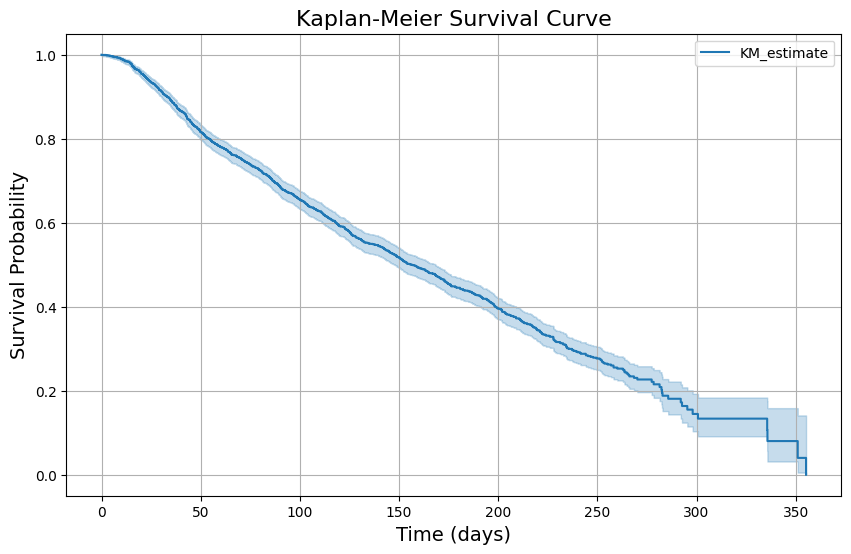

In [196]:
# Vytvorenie objektu KaplanMeierFitter
kmf = KaplanMeierFitter()

# Fitnutie dát (time = čas, event = udalosť)
kmf.fit(durations=data['time'], event_observed=data['event'])

# Vykreslenie Kaplan-Meierovej krivky
plt.figure(figsize=(10, 6))
kmf.plot_survival_function(ci_show=True)

plt.title('Kaplan-Meier Survival Curve', fontsize=16)
plt.xlabel('Time (days)', fontsize=14)
plt.ylabel('Survival Probability', fontsize=14)
plt.grid(True)
plt.show()

### V tejto casti su vsetky atributy, ktore mali hodnoty p value < 0.05, postupne odoberam

In [197]:
relevant_attributes = [
    'event',
    'time',
    'Age at Diagnosis',  
    'Type of Breast Surgery',  
    'Chemotherapy',  
    'Cohort',  
    'ER Status',  
    'Neoplasm Histologic Grade',  
    'HER2 Status',  
    'Hormone Therapy',  
    'Inferred Menopausal State',  
    'Lymph nodes examined positive',  
    'Nottingham prognostic index',  
    'PR Status',  
    'Radio Therapy',  
    'Relapse Free Status (Months)',  
    'Relapse Free Status',  
    'Tumor Size',  
    'Tumor Stage',  
    'Subtype_Her2',  
    'Subtype_LumA',  
    'Subtype_LumB',  
    'Subtype_claudin-low',  
    'HER2_Status_Neutral',  
    'Tumor_Subtype_Tubular/ cribriform',  
    'IC_10',  
    'IC_3',  
    'IC_4ER+',  
    'IC_5',  
    'IC_6',  
    'IC_9',  
    '3-GCS_ER+/HER2- Low Prolif',  
    '3-GCS_HER2+'  
]


In [198]:
relevant_attributes_df = data[relevant_attributes]

In [199]:
from lifelines import CoxPHFitter
cph = CoxPHFitter(alpha=0.05)
cph.fit(relevant_attributes_df, duration_col = 'time', event_col = 'event')
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1976 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1976
number of events observed = 1141
   partial log-likelihood = -6858.53
         time fit was run = 2025-03-18 15:49:04 UTC

---
                                   coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                          
Age at Diagnosis                   0.05      1.05      0.00            0.04            0.06                1.04                1.06
Type of Breast Surgery             0.10      1.10      0.08           -0.06            0.25                0.94                1.29
Chemotherapy                       0.27      1.31      0.11            0.05            0.48                1.06                1.61
Cohort                             0.09      1.09      0.03            0.04            0.14                1.04                1.15
ER Status                         -0.37      0.69      0.13           -0.63           -0.12                0.54                0.88
Neoplasm Histologic Grade         -0.03      0.97      0.07           -0.17            0.11                0.84                1.12
HER2 Status                       -0.06      0.95      0.19           -0.42            0.31                0.65                1.37
Hormone Therapy                    0.02      1.02      0.07           -0.13            0.16                0.88                1.18
Inferred Menopausal State         -0.21      0.81      0.12           -0.45            0.03                0.64                1.03
Lymph nodes examined positive      0.00      1.00      0.01           -0.01            0.02                0.99                1.02
Nottingham prognostic index        0.15      1.16      0.05            0.06            0.24                1.06                1.27
PR Status                         -0.11      0.90      0.07           -0.25            0.04                0.78                1.04
Radio Therapy                     -0.06      0.94      0.08           -0.22            0.09                0.81                1.09
Relapse Free Status (Months)      -0.02      0.98      0.00           -0.02           -0.02                0.98                0.98
Relapse Free Status               -0.11      0.89      0.09           -0.28            0.06                0.76                1.06
Tumor Size                         0.00      1.00      0.00           -0.00            0.01                1.00                1.01
Tumor Stage                        0.16      1.18      0.07            0.03            0.30                1.03                1.34
Subtype_Her2                      -0.07      0.93      0.13           -0.32            0.18                0.72                1.20
Subtype_LumA                      -0.13      0.88      0.12           -0.36            0.09                0.70                1.10
Subtype_LumB                      -0.13      0.87      0.12           -0.37            0.10                0.69                1.11
Subtype_claudin-low                0.08      1.08      0.14           -0.19            0.34                0.83                1.41
HER2_Status_Neutral                0.09      1.10      0.09           -0.08            0.27                0.92                1.31
Tumor_Subtype_Tubular/ cribriform  0.27      1.31      0.42           -0.55            1.09                0.58                2.96
IC_10                             -0.25      0.78      0.15           -0.55            0.04                0.58                1.04
IC_3                               0.04      1.04      0.10           -0.16            0.23                0.86                1.26
IC_4ER+                           -0.00      1.00      0.11           -0.22

In [200]:
#Atributy, ktore mali samostatne p-value < 0.05 (hladina vyznamnosti), postupne som odobrala aj tie, ktore takto naraz spustene mali p value > 0.05
relevant_attributes1 = [
    'event',
    'time',
    'Age at Diagnosis',
    'Type of Breast Surgery',
    'Chemotherapy',
    'Cohort',
    'ER Status',
    'Neoplasm Histologic Grade', 
    'HER2 Status',
    'Hormone Therapy',
    'Inferred Menopausal State',
    'Lymph nodes examined positive',
    'Nottingham prognostic index',
    'PR Status',
    'Radio Therapy',
    'Relapse Free Status (Months)', 
    'Relapse Free Status',
    'Tumor Size',
    'Tumor Stage'
]


In [201]:
relevant_attributes_df = data[relevant_attributes1]

In [202]:
from lifelines import CoxPHFitter
cph = CoxPHFitter(alpha=0.05)
cph.fit(relevant_attributes_df, duration_col = 'time', event_col = 'event')
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1976 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1976
number of events observed = 1141
   partial log-likelihood = -6869.54
         time fit was run = 2025-03-18 15:49:13 UTC

---
                               coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                      
Age at Diagnosis               0.05      1.05      0.00            0.04            0.06                1.04                1.06
Type of Breast Surgery         0.13      1.14      0.08           -0.02            0.28                0.98                1.32
Chemotherapy                   0.26      1.30      0.11            0.05            0.47                1.05                1.60
Cohort                         0.09      1.09      0.03            0.04            0.14                1.04                1.15
ER Status                     -0.40      0.67      0.10           -0.60           -0.20                0.55                0.82
Neoplasm Histologic Grade      0.01      1.01      0.07           -0.13            0.14                0.88                1.15
HER2 Status                    0.22      1.25      0.09            0.04            0.40                1.04                1.49
Hormone Therapy                0.02      1.02      0.07           -0.12            0.17                0.89                1.18
Inferred Menopausal State     -0.18      0.83      0.12           -0.42            0.06                0.66                1.06
Lymph nodes examined positive  0.00      1.00      0.01           -0.01            0.02                0.99                1.02
Nottingham prognostic index    0.14      1.15      0.04            0.05            0.22                1.05                1.25
PR Status                     -0.13      0.88      0.07           -0.27            0.01                0.76                1.01
Radio Therapy                 -0.04      0.96      0.08           -0.19            0.11                0.83                1.11
Relapse Free Status (Months)  -0.02      0.98      0.00           -0.02           -0.02                0.98                0.98
Relapse Free Status           -0.08      0.92      0.08           -0.25            0.08                0.78                1.09
Tumor Size                     0.00      1.00      0.00           -0.00            0.01                1.00                1.01
Tumor Stage                    0.17      1.18      0.07            0.04            0.30                1.04                1.35

                               cmp to      z      p  -log2(p)
covariate                                                    
Age at Diagnosis                 0.00  12.79 <0.005    122.06
Type of Breast Surgery           0.00   1.66   0.10      3.37
Chemotherapy                     0.00   2.44   0.01      6.10
Cohort                           0.00   3.31 <0.005     10.09
ER Status                        0.00  -3.94 <0.005     13.58
Neoplasm Histologic Grade        0.00   0.08   0.93      0.10
HER2 Status                      0.00   2.37   0.02      5.81
Hormone Therapy                  0.00   0.33   0.75      0.42
Inferred Menopausal State        0.00  -1.50   0.13      2.91
Lymph nodes examined positive    0.00   0.32   0.75      0.41
Nottingham prognostic index      0.00   3.03 <0.005      8.66
PR Status                        0.00  -1.78   0.08      3.73
Radio Therapy                    0.00  -0.56   0.57      0.80
Relapse Free Status (Months)     0.00 -28.50 <0.005    591.04
Relapse Free Status              0.00  -0.97   0.33      1.58
Tumor Size                       0.00   1.49   0.14      2.88
Tumor Stage                      0.00   2.56   0.01      6.57
---
Concordance = 0.89
Parti

##### Keď použijete viaceré atribúty v jednom modeli, model môže zachytiť interakcie medzi rôznymi premennými. To znamená, že účinok jedného atribútu môže byť ovplyvnený prítomnosťou iných atribútov v modeli. Inými slovami, koeficienty a p-hodnoty sa môžu zmeniť, pretože model sa teraz snaží odhadnúť účinky všetkých atribútov súčasne a môže sa zohľadniť, ako si vzájomne ovplyvňujú.

In [203]:
#Atributy, ktore mali samostatne p-value < 0.05 (hladina vyznamnosti), postupne som odobrala aj tie, ktore takto naraz spustene mali p value > 0.05
relevant_attributes2 = [
    'event',
    'time',
    'Age at Diagnosis',
    'Chemotherapy',
    'Cohort',
    'ER Status',
    'HER2 Status',
    'Nottingham prognostic index',
    'Relapse Free Status (Months)', 
    'Tumor Stage'
]

In [204]:
relevant_attributes_df = data[relevant_attributes2]
cph = CoxPHFitter(alpha=0.05)
cph.fit(relevant_attributes_df, duration_col = 'time', event_col = 'event')
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1976 total observations, 835 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1976
number of events observed = 1141
   partial log-likelihood = -6877.70
         time fit was run = 2025-03-18 15:49:21 UTC

---
                              coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                     
Age at Diagnosis              0.05      1.05      0.00            0.04            0.05                1.04                1.05
Chemotherapy                  0.26      1.30      0.11            0.06            0.47                1.06                1.60
Cohort                        0.09      1.09      0.03            0.04            0.14                1.04                1.15
ER Status                    -0.47      0.62      0.09           -0.64           -0.30                0.53                0.74
HER2 Status                   0.24      1.27      0.09            0.06            0.42                1.07                1.52
Nottingham prognostic index   0.15      1.16      0.03            0.09            0.21                1.09                1.24
Relapse Free Status (Months) -0.02      0.98      0.00           -0.02           -0.02                0.98                0.98
Tumor Stage                   0.23      1.26      0.06            0.12            0.35                1.12                1.42

                              cmp to      z      p  -log2(p)
covariate                                                   
Age at Diagnosis                0.00  16.00 <0.005    189.09
Chemotherapy                    0.00   2.50   0.01      6.34
Cohort                          0.00   3.36 <0.005     10.31
ER Status                       0.00  -5.38 <0.005     23.68
HER2 Status                     0.00   2.67   0.01      7.06
Nottingham prognostic index     0.00   4.76 <0.005     18.99
Relapse Free Status (Months)    0.00 -37.04 <0.005    995.00
Tumor Stage                     0.00   3.94 <0.005     13.58
---
Concordance = 0.89
Partial AIC = 13771.40
log-likelihood ratio test = 1922.00 on 8 df
-log2(p) of ll-ratio test = inf

### Vizualizacie pomocou Kaplan-Meierovych kriviek

#### Atribut Nottingham prognostic index

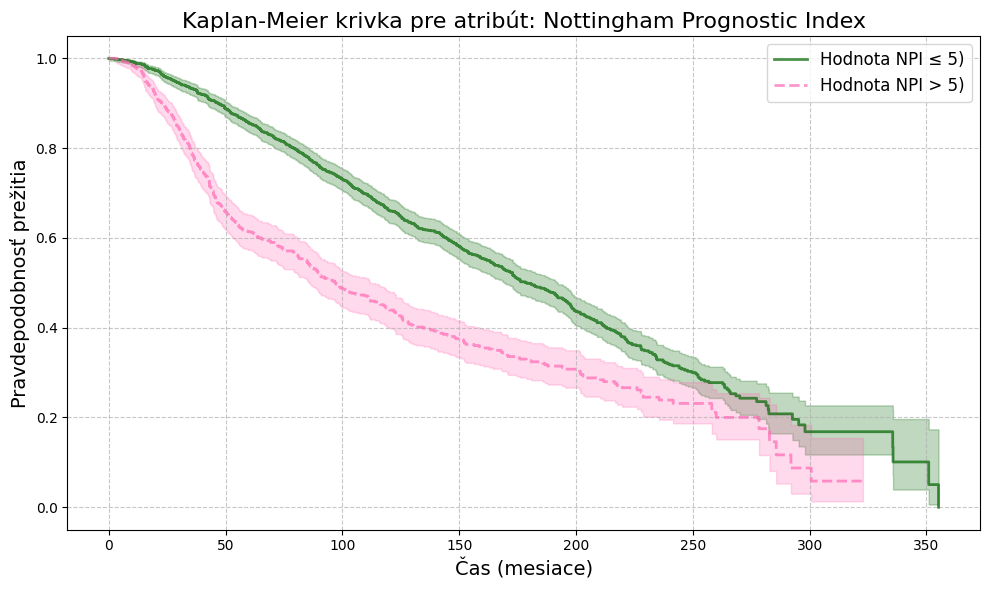

In [122]:
threshold = 5  #prahova hodnota pre rozdelenie do dvoch skupin, budeme porovnavat pacientov s Nottingham prognostic indexom <= 5 a > 5

# Rozdelenie pacientov do dvoch skupín podľa hodnoty Nottingham prognostic index
low_group = data[data['Nottingham prognostic index'] <= threshold]
high_group = data[data['Nottingham prognostic index'] > threshold]

# Vytvorenie Kaplan-Meier modelu pre každú skupinu
kmf_low = KaplanMeierFitter()
kmf_high = KaplanMeierFitter()

# Fit pre Nottingham prognostic index (nízky a vysoký index) s intervalmi spoľahlivosti
kmf_low.fit(low_group['time'], event_observed=low_group['event'], label="Nízky NPI (≤ 5)", alpha=0.05)
kmf_high.fit(high_group['time'], event_observed=high_group['event'], label="Vysoký NPI (> 5)", alpha=0.05)

plt.figure(figsize=(10, 6))

# Zobrazenie Kaplan-Meierových kriviek 
kmf_low.plot(ci_show=True, color="darkgreen", linewidth=2, linestyle='-', label="Hodnota NPI ≤ 5)", alpha=0.7)
kmf_high.plot(ci_show=True, color="hotpink", linewidth=2, linestyle='--', label="Hodnota NPI > 5)", alpha=0.7)

plt.title('Kaplan-Meier krivka pre atribút: Nottingham Prognostic Index', fontsize=16)
plt.xlabel('Čas (mesiace)', fontsize=14)
plt.ylabel('Pravdepodobnosť prežitia', fontsize=14)
plt.legend(loc='best', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [123]:
#### Atribut HER2 Status

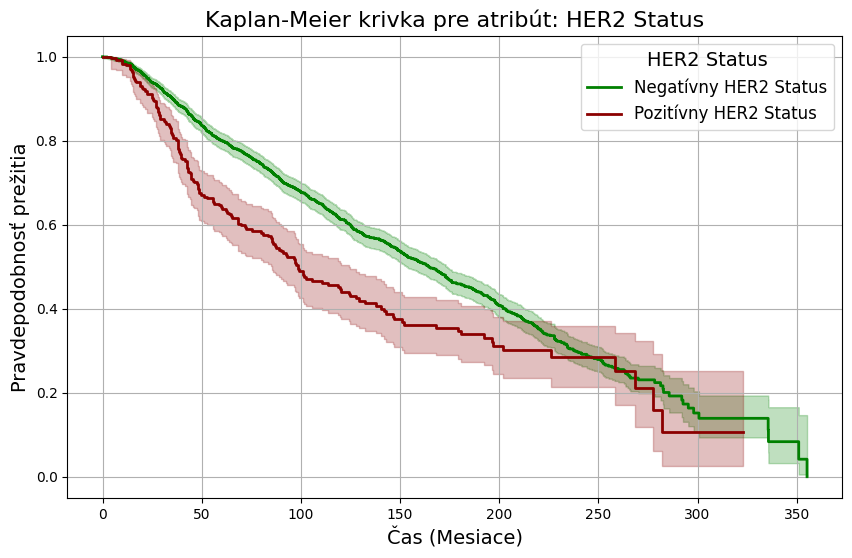

In [124]:
# Rozdelenie pacientov do dvoch skupín podľa HER2 statusu
negative_group = data[data['HER2 Status'] == 0]
positive_group = data[data['HER2 Status'] == 1]

# Vytvorenie Kaplan-Meier modelu pre každú skupinu
kmf_negative = KaplanMeierFitter()
kmf_positive = KaplanMeierFitter()

# Fit pre HER2 Status = 0 (Negatívny) a HER2 Status = 1 (Pozitívny)
kmf_negative.fit(negative_group['time'], event_observed=negative_group['event'], label="Negatívny HER2 Status")
kmf_positive.fit(positive_group['time'], event_observed=positive_group['event'], label="Pozitívny HER2 Status")

# Vytvorenie grafu
plt.figure(figsize=(10, 6))

# Zobrazenie Kaplan-Meier krivky pre negatívny a pozitivny HER2 status
kmf_negative.plot(ci_show=True, color='green', linewidth=2)
kmf_positive.plot(ci_show=True, color='darkred', linewidth=2)

plt.title('Kaplan-Meier krivka pre atribút: HER2 Status', fontsize=16)
plt.xlabel('Čas (Mesiace)', fontsize=14)
plt.ylabel('Pravdepodobnosť prežitia', fontsize=14)
plt.legend(title='HER2 Status', title_fontsize=14, loc='upper right', fontsize=12)
plt.grid(True)
plt.show()

#### Analyzovanie vplyv atributu Veku pri diagnóze na pravdepodobnosť úmrtia pomocou Coxovho regresného modelu. Vizualizujeme ho ako Partial Dependence Plot (PDP).

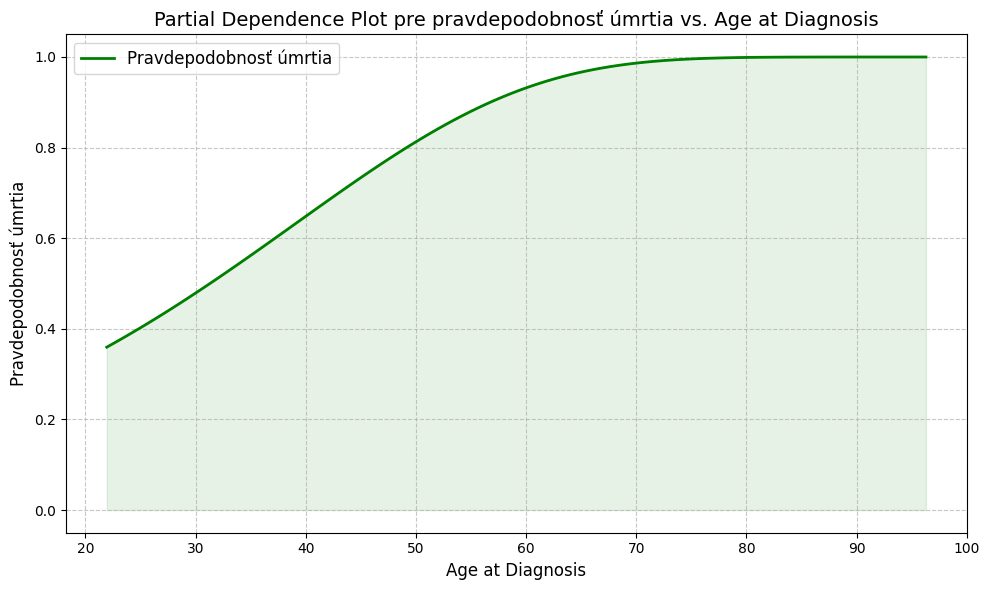

In [125]:
# Načítanie údajov a nastavenie modelu
duration_col = 'time'
event_col = 'event'

# Fitneme CoxPH model na relevantných atribútoch
cph = CoxPHFitter()
cph.fit(relevant_attributes_df, duration_col=duration_col, event_col=event_col)

# Rozsah hodnôt, ktorý chceme skúmať pre 'Age at Diagnosis'
age_values = np.linspace(relevant_attributes_df['Age at Diagnosis'].min(), 
                         relevant_attributes_df['Age at Diagnosis'].max(), 
                         100)

# Inicializujeme zoznam na ukladanie priemerných pravdepodobností úmrtia pre jednotlivé hodnoty veku
death_probs = []

# Pre každú hodnotu veku vypočítame pravdepodobnosť úmrtia
for age in age_values:
    # Vytvoríme kópiu dátového rámca a nastavíme Age at Diagnosis na aktuálnu hodnotu
    X_temp = relevant_attributes_df.copy()
    X_temp['Age at Diagnosis'] = age
    
    # Vypočítame hazard pre túto hodnotu veku a spriemerujeme ho
    mean_hazard = cph.predict_partial_hazard(X_temp).mean()
    
    # Prevod na pravdepodobnosť úmrtia
    death_prob = 1 - np.exp(-mean_hazard)
    death_probs.append(death_prob)

# Vylepšená vizualizácia PDP pre pravdepodobnosť úmrtia podľa veku
plt.figure(figsize=(10, 6))

plt.plot(age_values, death_probs, color='green', linewidth=2, label="Pravdepodobnosť úmrtia")

# Pridanie vyhladenia krivky pomocou interpolácie pre hladší vzhľad
from scipy.interpolate import make_interp_spline
spl = make_interp_spline(age_values, death_probs, k=3)
age_smooth = np.linspace(age_values.min(), age_values.max(), 300)
death_probs_smooth = spl(age_smooth)
plt.plot(age_smooth, death_probs_smooth, color='green', linestyle='--', linewidth=1)

plt.fill_between(age_smooth, death_probs_smooth, color='green', alpha=0.1)
plt.title("Partial Dependence Plot pre pravdepodobnosť úmrtia vs. Age at Diagnosis", fontsize=14)
plt.xlabel("Age at Diagnosis", fontsize=12)
plt.ylabel("Pravdepodobnosť úmrtia", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()


#### Analyzovanie vplyv atributu Relapse Free Status (Months) na pravdepodobnosť úmrtia pomocou Coxovho regresného modelu. Vizualizujeme ho ako Partial Dependence Plot (PDP).

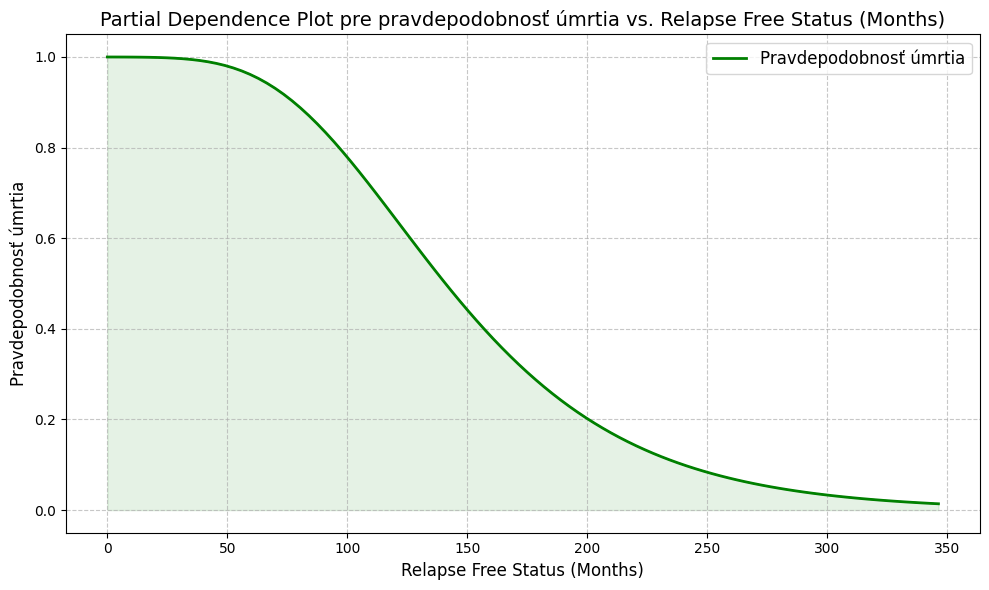

In [126]:
# Načítanie údajov a nastavenie modelu
duration_col = 'time'
event_col = 'event'

# Fitneme CoxPH model na relevantných atribútoch
cph = CoxPHFitter()
cph.fit(relevant_attributes_df, duration_col=duration_col, event_col=event_col)

# Rozsah hodnôt, ktorý chceme skúmať pre 'Relapse Free Status (Months)'
age_values = np.linspace(relevant_attributes_df['Relapse Free Status (Months)'].min(), 
                         relevant_attributes_df['Relapse Free Status (Months)'].max(), 
                         100)

# Inicializujeme zoznam na ukladanie priemerných pravdepodobností úmrtia pre jednotlivé hodnoty
death_probs = []

# Pre každú hodnotu veku vypočítame pravdepodobnosť úmrtia
for age in age_values:
    # Vytvoríme kópiu dátového rámca a nastavíme hodnotu 'Relapse Free Status (Months)' na aktuálnu hodnotu
    X_temp = relevant_attributes_df.copy()
    X_temp['Relapse Free Status (Months)'] = age
    
    # Vypočítame hazard pre túto hodnotu a spriemerujeme ho
    mean_hazard = cph.predict_partial_hazard(X_temp).mean()
    
    # Prevod na pravdepodobnosť úmrtia
    death_prob = 1 - np.exp(-mean_hazard)
    death_probs.append(death_prob)

plt.figure(figsize=(10, 6))
plt.plot(age_values, death_probs, color='green', linewidth=2, label="Pravdepodobnosť úmrtia")

spl = make_interp_spline(age_values, death_probs, k=3)
age_smooth = np.linspace(age_values.min(), age_values.max(), 300)
death_probs_smooth = spl(age_smooth)
plt.plot(age_smooth, death_probs_smooth, color='green', linestyle='--', linewidth=1)
plt.fill_between(age_smooth, death_probs_smooth, color='green', alpha=0.1)
plt.title("Partial Dependence Plot pre pravdepodobnosť úmrtia vs. Relapse Free Status (Months)", fontsize=14)
plt.xlabel("Relapse Free Status (Months)", fontsize=12)
plt.ylabel("Pravdepodobnosť úmrtia", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()